## Standardlization

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sb
import matplotlib.pyplot as plot
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

df = pd.read_csv("../../train.csv")

df.sample(3)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
63,64,0,3,"Skoog, Master. Harald",male,4.0,3,2,347088,27.9000,NaN,S
753,754,0,3,"Jonkoff, Mr. Lalio",male,23.0,0,0,349204,7.8958,NaN,S
848,849,0,2,"Harper, Rev. John",male,28.0,0,1,248727,33.0000,NaN,S


before using any scalar, take input/ouput data and col with test and train data

In [10]:
#build a new df
newds = pd.DataFrame({
  "Survived" : df["Survived"],
  "Pclass" : df["Pclass"],
  "Fare" : df["Fare"]
})

newds.sample(3)

,Survived,Pclass,Fare
874,1,2,24.000
461,0,3,8.050
393,1,1,113.275


do split data to testing and traning

In [15]:
X = newds.iloc[:, 1:] #row, col
Y = newds.iloc[:,:1]

X_train: pd.DataFrame #input is df
X_test: pd.DataFrame
Y_train: pd.Series #op is row
Y_test: pd.Series

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.33, random_state=45)

print(X_train.shape, X_test.shape, Y_train.shape, Y_test.shape)

(596, 2) (295, 2) (596, 1) (295, 1)


now do standardscaler

In [16]:
scaler =  StandardScaler()

In [19]:
X_train, X_test

(     Pclass      Fare
 126       3    7.7500
 369       1   69.3000
 61        1   80.0000
 812       2   10.5000
 182       3   31.3875
 ..      ...       ...
 725       3    8.6625
 607       1   30.5000
 544       1  106.4250
 643       3   56.4958
 414       3    7.9250
 
 [596 rows x 2 columns],
      Pclass     Fare
 248       1  52.5542
 197       3   8.4042
 133       2  26.0000
 169       3  56.4958
 736       3  34.3750
 ..      ...      ...
 570       2  10.5000
 696       3   8.0500
 743       3  16.1000
 274       3   7.7500
 584       3   8.7125
 
 [295 rows x 2 columns])

In [ ]:
#always do standardization of input data of train

scaler.fit(X_train) #via that scaler has mean and SD of all ip cols

#get standard values
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [29]:
scaler.mean_ # Pclass mean, fare mean

array([ 2.28187919, 33.55448641])

In [18]:
X_train_scaled, X_test_scaled

(array([[ 0.84678297, -0.50061546],
        [-1.51154717,  0.69347463],
        [-1.51154717,  0.90105812],
        ...,
        [-1.51154717,  1.41371175],
        [ 0.84678297,  0.44506897],
        [ 0.84678297, -0.4972204 ]]),
 array([[-1.51154717e+00,  3.68600645e-01],
        [ 8.46782970e-01, -4.87923765e-01],
        [-3.32382100e-01, -1.46559502e-01],
        [ 8.46782970e-01,  4.45068972e-01],
        [ 8.46782970e-01,  1.59182315e-02],
        [-1.51154717e+00,  4.16049963e-01],
        [ 8.46782970e-01, -5.10315622e-01],
        [ 8.46782970e-01, -5.00130451e-01],
        [ 8.46782970e-01, -4.94795361e-01],
        [ 8.46782970e-01, -4.82912661e-01],
        [ 8.46782970e-01, -4.71999977e-01],
        [ 8.46782970e-01, -4.98593945e-01],
        [-3.32382100e-01, -1.46559502e-01],
        [-3.32382100e-01, -4.05553859e-01],
        [ 8.46782970e-01, -5.00130451e-01],
        [ 8.46782970e-01, -4.98593945e-01],
        [ 8.46782970e-01, -4.97220402e-01],
        [ 8.46782970e

In [26]:
#here both ara np array so get back datafram
X_train_df = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_df = pd.DataFrame(X_test_scaled, columns=X_test.columns)

In [27]:
X_train_df.sample(3)

,Pclass,Fare
249,0.846783,-0.500615
70,0.846783,-0.505062
26,0.846783,-0.301762


In [36]:
#orign data mean
np.round(X_train.describe())

,Pclass,Fare
count,596.0,596.0
mean,2.0,34.0
std,1.0,52.0
min,1.0,0.0
25%,1.0,8.0
50%,3.0,15.0
75%,3.0,31.0
max,3.0,512.0


In [35]:
#check mean = 0  and SD = 1
np.round(X_train_df.describe())

,Pclass,Fare
count,596.0,596.0
mean,0.0,0.0
std,1.0,1.0
min,-2.0,-1.0
25%,-2.0,-0.0
50%,1.0,-0.0
75%,1.0,-0.0
max,1.0,9.0


visualize via graph

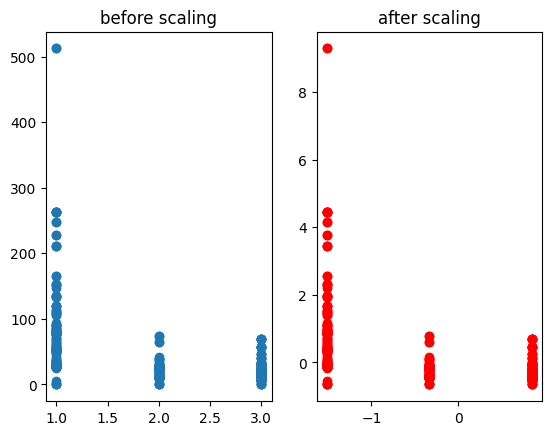

In [51]:
g1 : plot
g2 : plot
fig, (g1, g2) = plot.subplots(ncols = 2) 
#g1 - first graph
#g2 - second graph so ncols = 2

g1.scatter(x=X_train["Pclass"], y=X_train["Fare"])
g1.set_title("before scaling")
g2.scatter(x=X_train_df["Pclass"], y=X_train_df["Fare"], color="red")
g2.set_title("after scaling")
plot.show()

via graph we can see outliears are stay not remove